# Ejemplo de visualización de datos

Este notebook es para saber cómo utilizar las funciones definidas en `src/tfm_plots.py`.

El módulo tiene funciones generales de visualización que pueden utilizarse sobre los DataFrames estandarizados generados por
`src/tfm_io.py`.

Las funciones permiten representar series temporales, distribuciones de variables numéricas, frecuencias de variables categóricas, valores agregados por categoría, relaciones entre variables numéricas y porcentajes de valores ausentes.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )


from src.tfm_io import (
    load_data_directory,
    summarize_datasets,
)

from src.tfm_plots import (
    plot_time_series,
    plot_distribution,
    plot_category_counts,
    plot_aggregated_bars,
    plot_scatter,
    plot_missing_values,
)


DATA_DIR = PROJECT_ROOT / 'data'

RESULTS_DIR = PROJECT_ROOT / 'results'


print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIR}')
print(f'Results directory: {RESULTS_DIR}')

Project root: c:\Users\Usuario\Documents\Master_BigData_DataScience_IA\TFM\TFM-Hosteleria-AI
Data directory: c:\Users\Usuario\Documents\Master_BigData_DataScience_IA\TFM\TFM-Hosteleria-AI\data
Results directory: c:\Users\Usuario\Documents\Master_BigData_DataScience_IA\TFM\TFM-Hosteleria-AI\results


## Carga de los datos

Primero utilizamos `load_data_directory()` para leer todos los archivos
Excel disponibles y obtener los datasets estandarizados.

El módulo `tfm_plots.py` trabaja directamente sobre estos DataFrames.

In [2]:
datasets, load_errors = load_data_directory(
    DATA_DIR
)


summary = summarize_datasets(
    datasets
)


display(summary)


if not load_errors.empty:
    print('Files with loading errors:')

    display(load_errors)

else:
    print('All files were loaded correctly.')

,dataset,rows,columns
0,article_sales_periodic,5532,13
1,article_sales_summary,251,13
2,articles,405,5
3,departments,23,4
4,menu,405,3
5,reservations,21341,20
6,tickets,6709,11
7,tips,1697,11


All files were loaded correctly.


In [3]:
article_sales_periodic = (
    datasets['article_sales_periodic']
)

article_sales_summary = (
    datasets['article_sales_summary']
)

articles = datasets['articles']

menu = datasets['menu']

departments = datasets['departments']

tickets = datasets['tickets']

tips = datasets['tips']

reservations = datasets['reservations']

## Series temporales

`plot_time_series()` agrupa observaciones utilizando una frecuencia temporal y representa la evolución de una variable.

Las agregaciones disponibles son `count`, `nunique`, `sum`, `mean` y `median`

La frecuencia se indica utilizando frecuencias temporales de pandas. Por ejemplo `D`: día, `W`: semana o `MS`: inicio de mes.

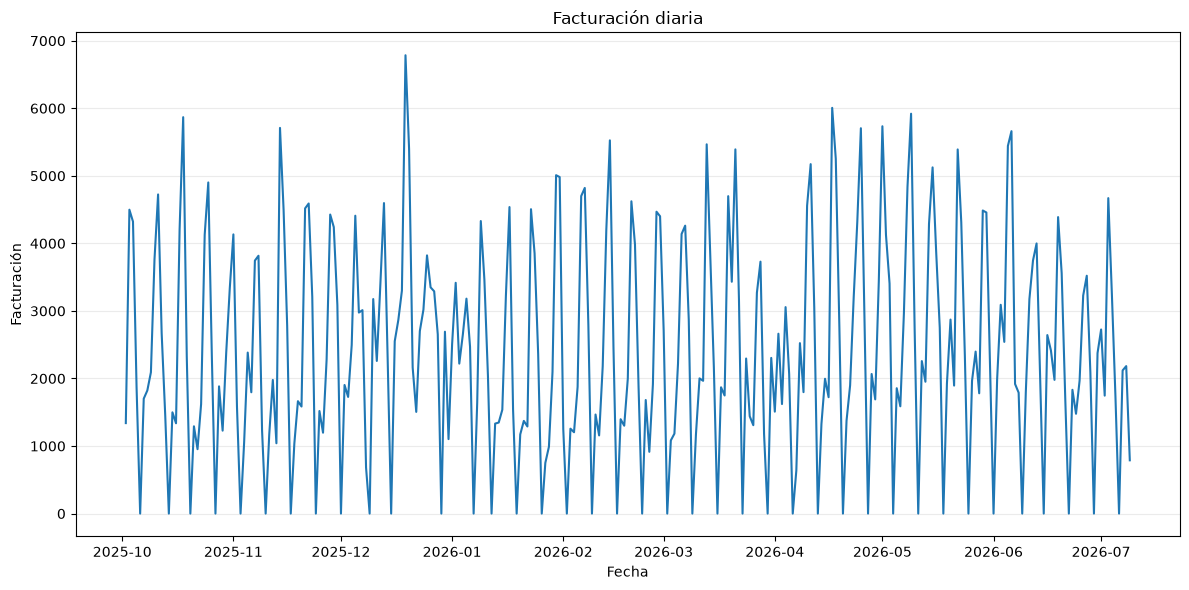

In [4]:
fig, ax = plot_time_series(
    tickets,
    date_column='date',
    value_column='document_total',
    aggregation='sum',
    frequency='D',
    title='Facturación diaria',
    xlabel='Fecha',
    ylabel='Facturación',
)


plt.show()

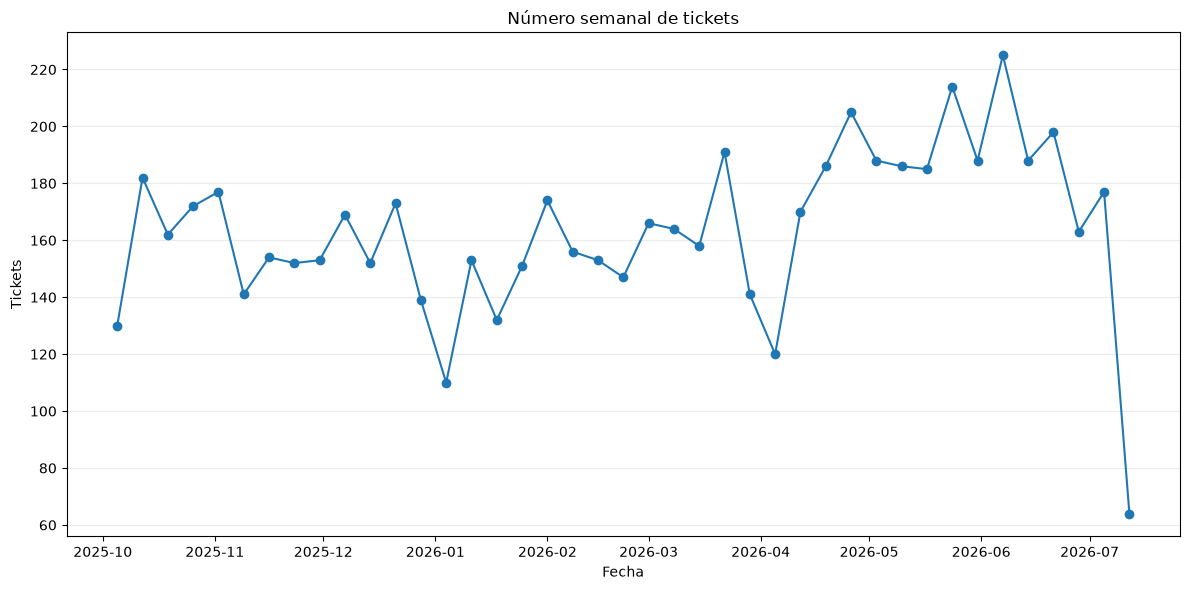

In [5]:
fig, ax = plot_time_series(
    tickets,
    date_column='date',
    value_column='document_id',
    aggregation='nunique',
    frequency='W',
    title='Número semanal de tickets',
    xlabel='Fecha',
    ylabel='Tickets',
    marker=True,
)


plt.show()

## Distribución de una variable numérica

`plot_distribution()` crea un histograma de una columna numérica. Puede utilizarse, por ejemplo, para ver la distribución del importe de los tickets.

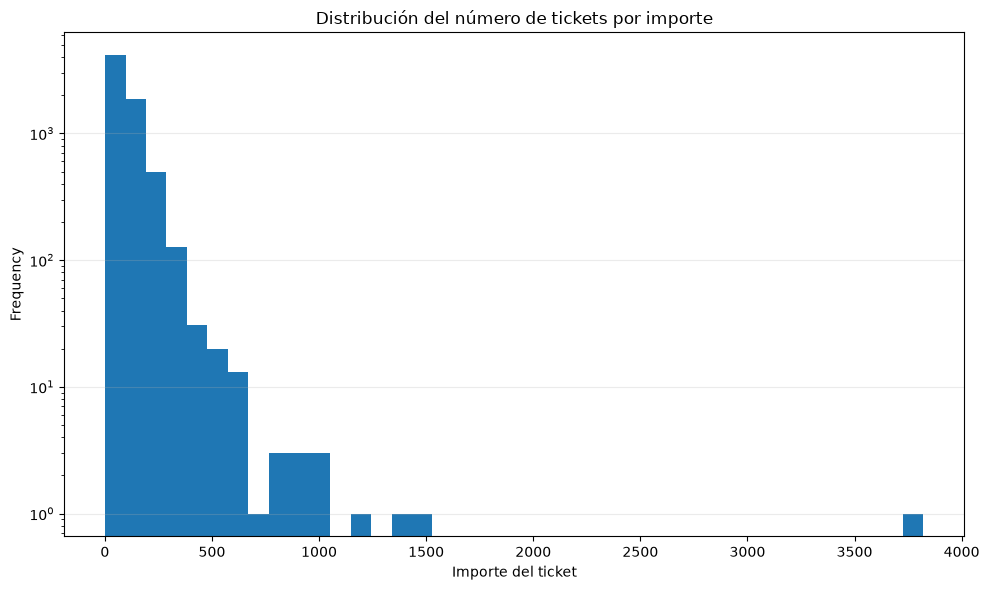

In [6]:
fig, ax = plot_distribution(
    tickets,
    column='document_total',
    bins=40,
    title='Distribución del número de tickets por importe',
    xlabel='Importe del ticket',
    yscale='log',
)


plt.show()

## Frecuencia de variables categóricas

`plot_category_counts()` cuenta automáticamente el número de observaciones de cada categoría.

Puede utilizarse para variables como estado de una reserva, turno, origen, zona o tipo de reserva.

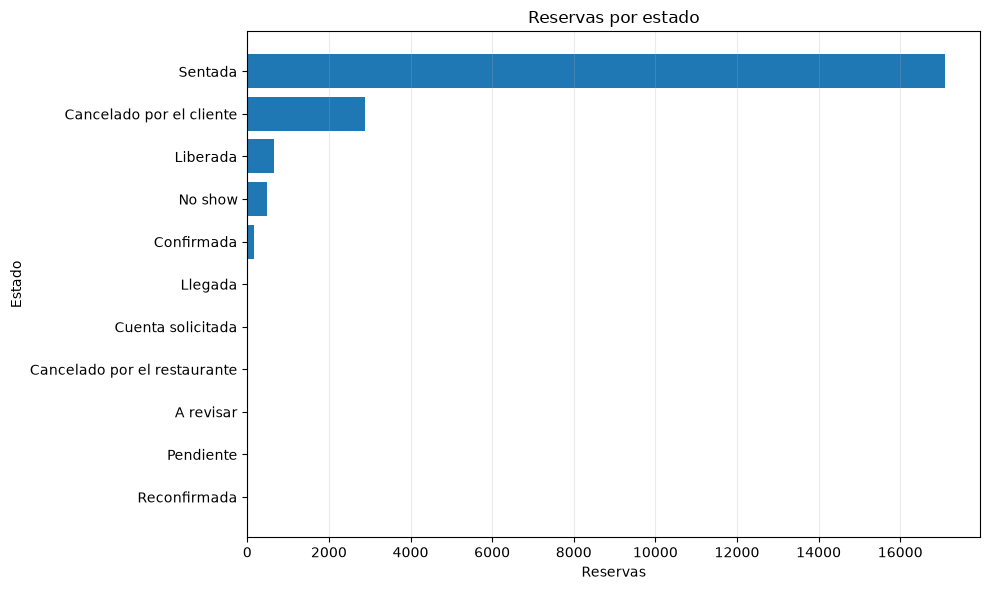

In [7]:
fig, ax = plot_category_counts(
    reservations,
    category_column='status',
    title='Reservas por estado',
    xlabel='Reservas',
    ylabel='Estado',
)


plt.show()

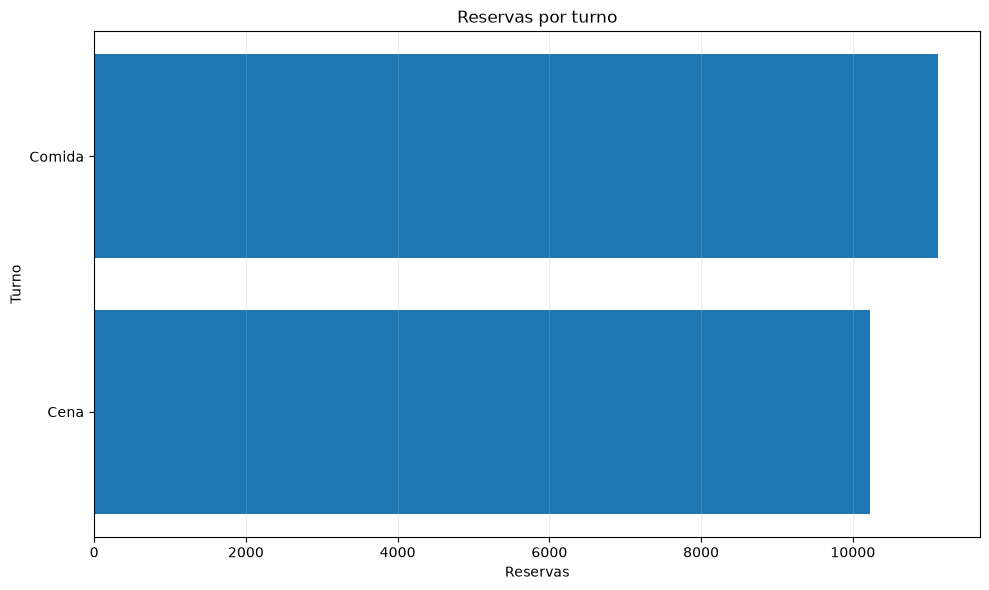

In [8]:
fig, ax = plot_category_counts(
    reservations,
    category_column='shift',
    title='Reservas por turno',
    xlabel='Reservas',
    ylabel='Turno',
)


plt.show()

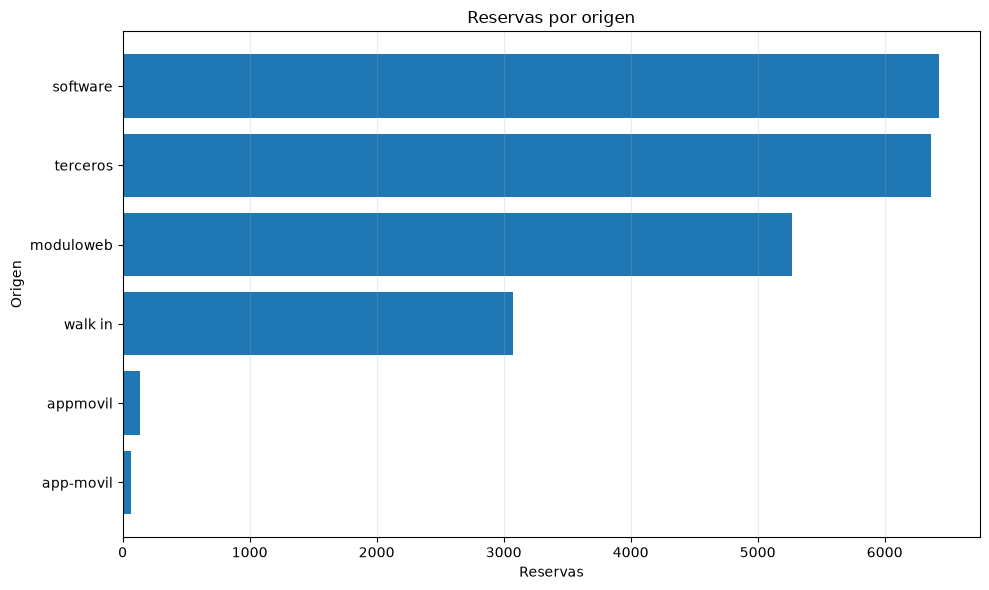

In [9]:
fig, ax = plot_category_counts(
    reservations,
    category_column='origin',
    top_n=10,
    title='Reservas por origen',
    xlabel='Reservas',
    ylabel='Origen',
)


plt.show()

## Valores agregados por categoría

`plot_aggregated_bars()` agrupa los datos por una variable categórica y aplica una agregación sobre una variable numérica.

Las agregaciones disponibles son `sum`, `mean` y `median`

Esto nos permite observar artículos más vendidos, artículos con mayor facturación o ventas por departamento.

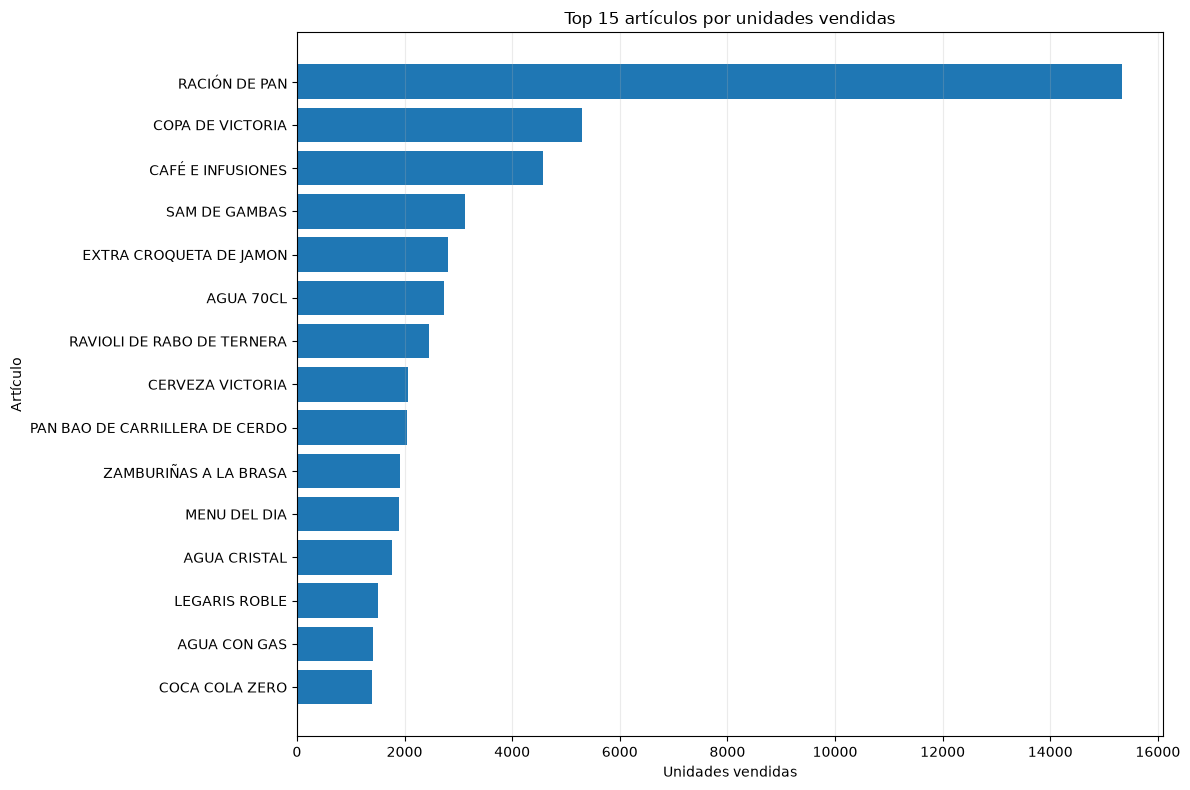

In [10]:
fig, ax = plot_aggregated_bars(
    article_sales_periodic,
    category_column='article_name',
    value_column='units',
    aggregation='sum',
    top_n=15,
    title='Top 15 artículos por unidades vendidas',
    xlabel='Unidades vendidas',
    ylabel='Artículo',
    figsize=(12, 8),
)


plt.show()

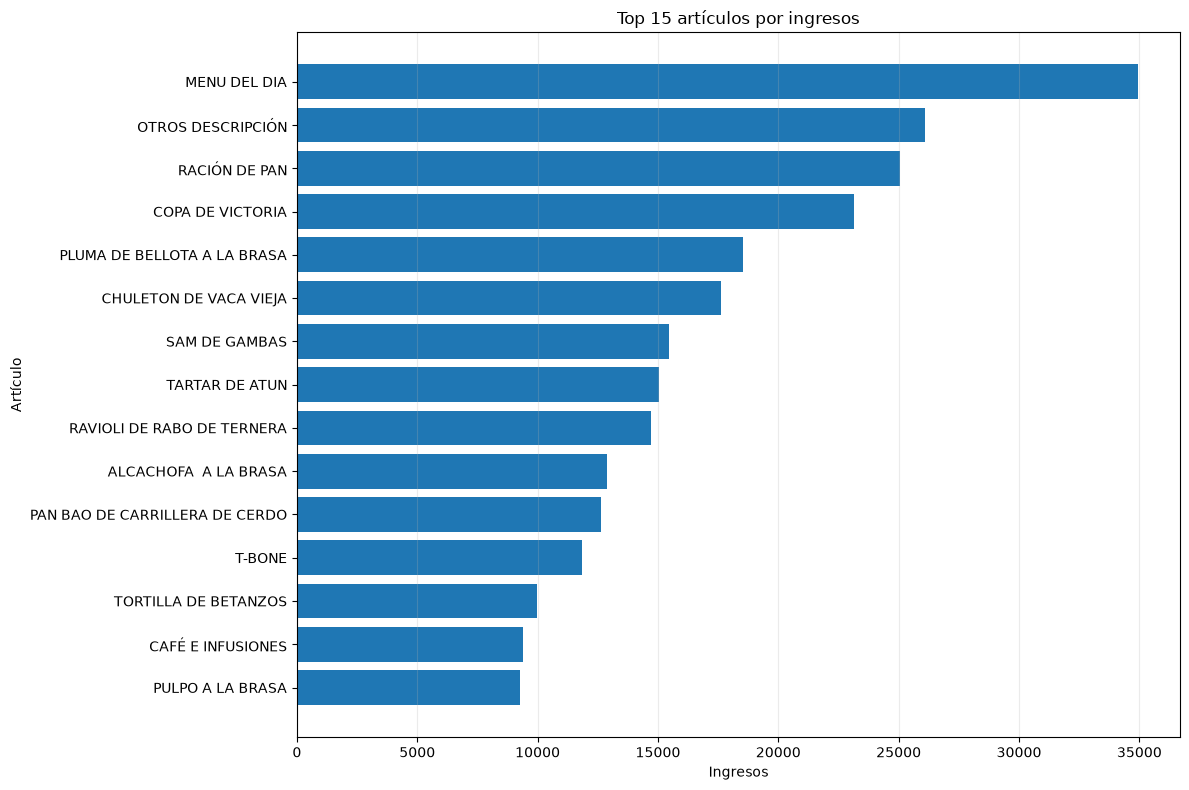

In [11]:
fig, ax = plot_aggregated_bars(
    article_sales_periodic,
    category_column='article_name',
    value_column='amount',
    aggregation='sum',
    top_n=15,
    title='Top 15 artículos por ingresos',
    xlabel='Ingresos',
    ylabel='Artículo',
    figsize=(12, 8),
)


plt.show()

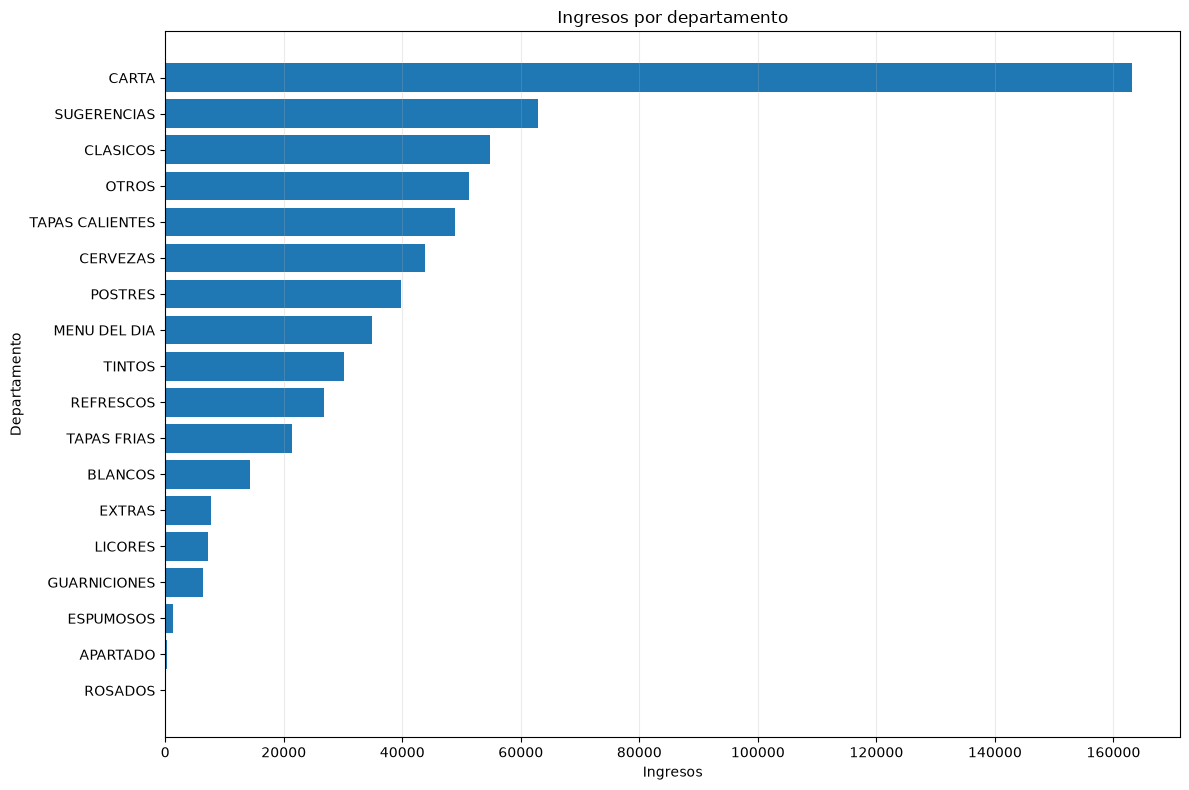

In [12]:
fig, ax = plot_aggregated_bars(
    article_sales_periodic,
    category_column='department_name',
    value_column='amount',
    aggregation='sum',
    top_n=None,
    title='Ingresos por departamento',
    xlabel='Ingresos',
    ylabel='Departamento',
    figsize=(12, 8),
)


plt.show()

## Relación entre dos variables numéricas

`plot_scatter()` crea un gráfico de dispersión entre dos columnas
numéricas.

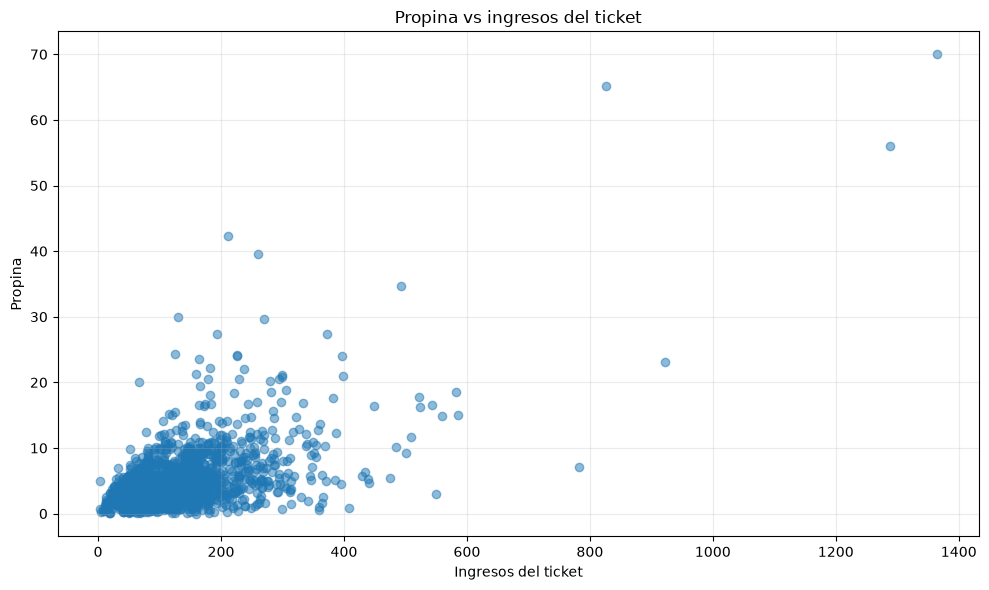

In [13]:
fig, ax = plot_scatter(
    tips,
    x_column='document_amount',
    y_column='tip',
    title='Propina vs ingresos del ticket',
    xlabel='Ingresos del ticket',
    ylabel='Propina',
    alpha=0.5,
)


plt.show()

## Valores ausentes

`plot_missing_values()` calcula el porcentaje de valores ausentes de
cada columna y representa el resultado.

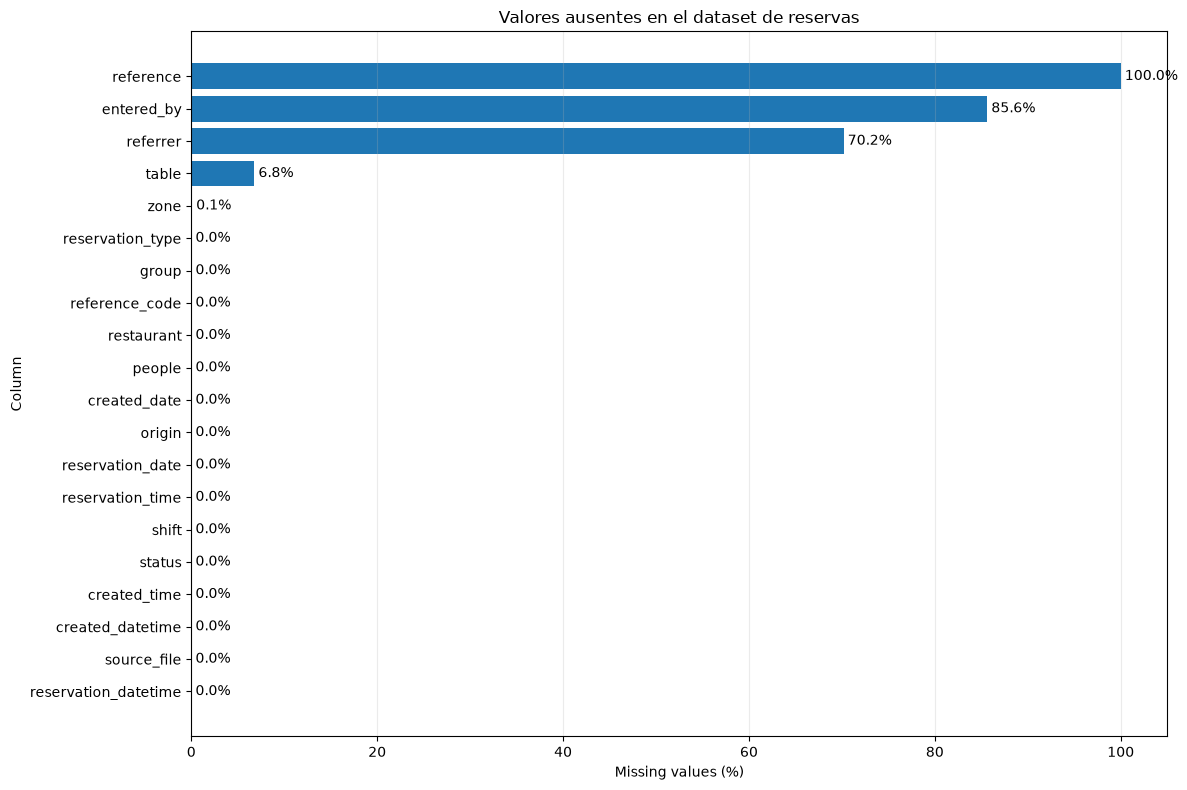

In [14]:
fig, ax = plot_missing_values(
    reservations,
    include_zero=True,
    title='Valores ausentes en el dataset de reservas',
    figsize=(12, 8),
)


plt.show()

## Guardar gráficos

Todas las funciones permiten utilizar el parámetro `save_path`. Si se indica una ruta, la figura se guarda automáticamente. 

La carpeta de destino se crea si todavía no existe.

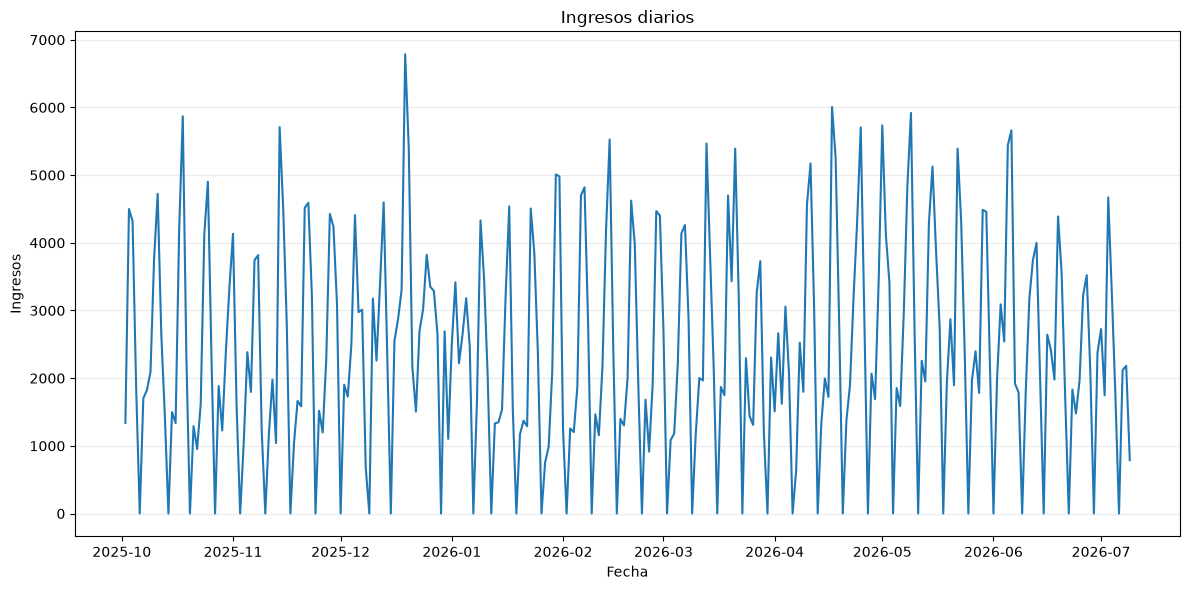

In [15]:
fig, ax = plot_time_series(
    tickets,
    date_column='date',
    value_column='document_total',
    aggregation='sum',
    frequency='D',
    title='Ingresos diarios',
    xlabel='Fecha',
    ylabel='Ingresos',
    save_path=(
        RESULTS_DIR
        / 'figures'
        / 'ingresos_diarios.png'
    ),
)


plt.show()

## Personalización de los gráficos

Todas las funciones devuelven dos objetos:

- `fig`: la figura de Matplotlib;
- `ax`: los ejes del gráfico.

Así podemos hacer modificaciones adicionales después de crear el gráfico.

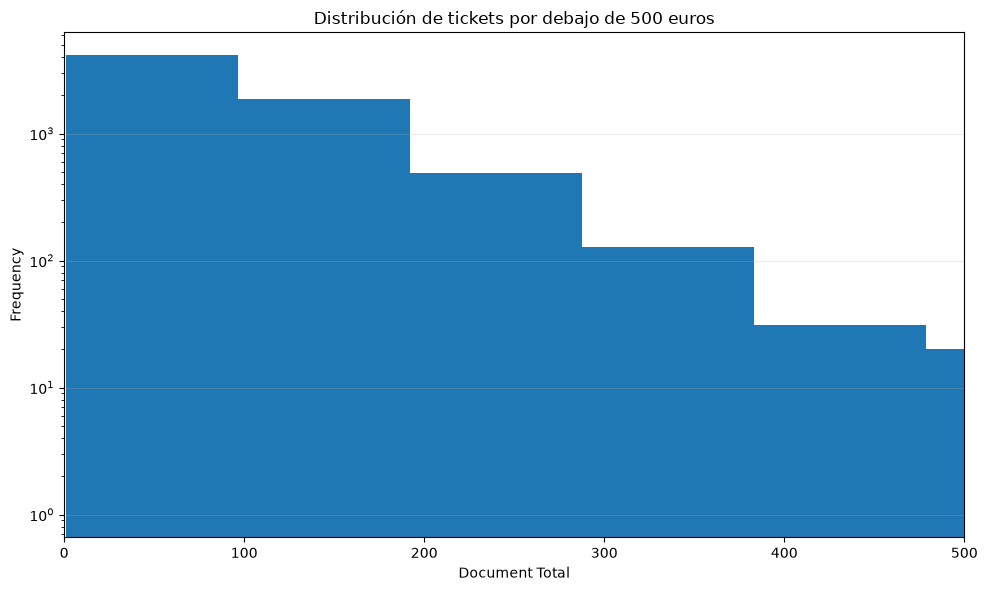

In [16]:
fig, ax = plot_distribution(
    tickets,
    column='document_total',
    bins=40,
)


ax.set_xlim(
    0,
    500,
)

ax.set_title(
    'Distribución de tickets por debajo de 500 euros'
)


plt.show()

## Diseño de `tfm_plots.py`

El módulo contiene las siguientes funciones públicas:

### `plot_time_series()`

Agrupa datos por una frecuencia temporal y representa su evolución como una serie temporal.

### `plot_distribution()`

Representa la distribución de una variable numérica mediante un histograma.

### `plot_category_counts()`

Cuenta el número de observaciones de cada categoría y representa los resultados mediante un gráfico de barras.

### `plot_aggregated_bars()`

Agrupa los datos por una categoría, agrega una variable numérica y representa los resultados mediante barras.

### `plot_scatter()`

Representa la relación entre dos variables numéricas mediante un gráfico de dispersión.

### `plot_missing_values()`

Calcula y representa el porcentaje de valores ausentes de cada columna.

Las funciones internas cuyo nombre comienza por `_` se utilizan para validar los datos, comprobar las columnas, generar etiquetas y guardar las figuras.

`tfm_plots.py` no realiza limpieza profunda, cruces entre tablas ni construcción de datasets para modelos. 